# Practice 02 — Linear Classification

Logistic regression in PyTorch, for a binary label and for one of $C$ classes.

The model still computes $\mathbf{z} = \mathbf{Xw}$ and the boundary $z = 0$ is still a line, hence
*linear* classification, so only the activation and the loss change.

| Output | Activation | Loss class |
|:---|:---|:---|
| real number | — | `nn.MSELoss` |
| binary label | sigmoid | `nn.BCEWithLogitsLoss` |
| one of $C$ classes | softmax | `nn.CrossEntropyLoss` |

**Binary**

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad
J = -\sum_n \bigl[\, y_n \ln \sigma(z_n) + (1 - y_n)\ln(1 - \sigma(z_n)) \,\bigr]$$

**Multi-class**

$$o_k = \frac{e^{z_k}}{\sum_q e^{z_q}}, \qquad
\hat{y} = \arg\max_k o_k, \qquad J = -\sum_n \log o^{(n)}_{y^{(n)}}$$

> **Logits.** Both loss classes apply the activation **inside** the loss, so `forward` returns the raw
> $\mathbf{z}$; adding sigmoid or softmax there would apply it twice.

---
## Step 0. Imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn import datasets

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['axes.unicode_minus'] = False

---
## Step 1. A Training Function

Every model below trains with the same four statements: forward, loss, `backward()`, `step()`.
Written once, so each model afterwards is a single call.

In [2]:
def train(model, X, y, optimizer, loss_fn, n_iter):
    # run n_iter full-batch updates and return the loss at each iteration
    loss_history = []
    for i in range(n_iter):
        z = model(X)              # logits
        loss = loss_fn(z, y)

        loss.backward()           # autograd computes the gradients
        optimizer.step()          # the optimizer updates every model parameter
        optimizer.zero_grad()     # clear the accumulated gradients

        loss_history.append(loss.item())
    return loss_history

---
## Step 2. Binary Classification — Data

Two Iris species (*setosa* and *versicolor*) described by two measurements, sepal length and sepal width.
The target is a single number per sample, 0 or 1.

`nn.BCEWithLogitsLoss` compares its input with a **float** target of the **same shape**, so the labels are
stored as `float32` of shape $(N, 1)$.

X_binary: torch.Size([100, 2]), dtype torch.float32
y_binary: torch.Size([100, 1]), dtype torch.float32
classes : [0 1]


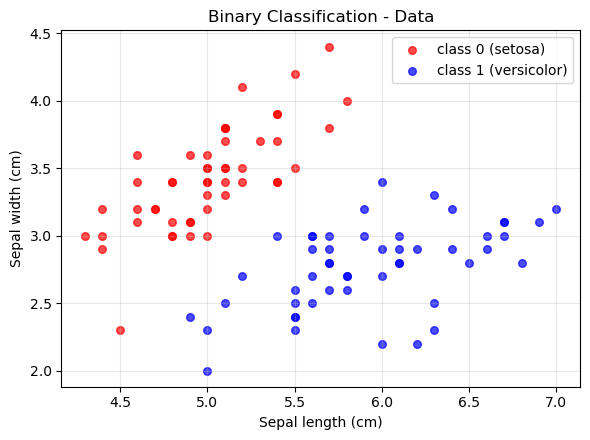

In [3]:
iris = datasets.load_iris()

mask = iris.target < 2                      # keep classes 0 and 1
X_binary_raw = iris.data[mask, :2]          # sepal length, sepal width
y_binary_raw = iris.target[mask]

X_binary = torch.tensor(X_binary_raw, dtype=torch.float32)                # (100, 2)
y_binary = torch.tensor(y_binary_raw, dtype=torch.float32).view(-1, 1)    # (100, 1)

print(f'X_binary: {X_binary.shape}, dtype {X_binary.dtype}')
print(f'y_binary: {y_binary.shape}, dtype {y_binary.dtype}')
print(f'classes : {np.unique(y_binary_raw)}')

class_0 = y_binary_raw == 0
class_1 = y_binary_raw == 1

plt.figure(figsize=(6, 4.5))
plt.scatter(X_binary_raw[class_0, 0], X_binary_raw[class_0, 1], c='r', s=30, alpha=0.7, label='class 0 (setosa)')
plt.scatter(X_binary_raw[class_1, 0], X_binary_raw[class_1, 1], c='b', s=30, alpha=0.7, label='class 1 (versicolor)')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.title('Binary Classification - Data')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 3. Binary Classification — Model and Training

The model is one `nn.Linear` layer with **one output unit**, returning the logit $z$.

Training is now a single call to the function from Step 1.

In [4]:
class BinaryClassifier(torch.nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, 1)

    def forward(self, x):
        z = self.linear(x)      # logit; the sigmoid is applied inside the loss
        return z


torch.manual_seed(42)
model_binary = BinaryClassifier(in_features=2)
print(model_binary)

BinaryClassifier(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


In [5]:
rho    = 0.01
n_iter = 200

optimizer = torch.optim.SGD(model_binary.parameters(), lr=rho)
loss_fn   = torch.nn.BCEWithLogitsLoss(reduction='sum')   # sigmoid + BCE in one

loss_history_binary = train(model_binary, X_binary, y_binary, optimizer, loss_fn, n_iter)

# the sigmoid is needed here, outside the loss, to turn logits into probabilities
with torch.no_grad():
    probability_binary = torch.sigmoid(model_binary(X_binary))
    y_pred_binary = (probability_binary >= 0.5).float()
    accuracy_binary = (y_pred_binary == y_binary).float().mean().item()

print(f'initial loss : {loss_history_binary[0]:.4f}')
print(f'final loss   : {loss_history_binary[-1]:.4f}')
print(f'accuracy     : {accuracy_binary:.1%}')

initial loss : 228.6959
final loss   : 4.8822
accuracy     : 99.0%


---
## Step 4. Binary Classification — Decision Boundary

The learned weights give the boundary directly: $x_2 = -(w_0 + w_1 x_1) / w_2$, where `bias` is $w_0$ and
`weight` holds $w_1, w_2$.

w0 (bias)   = -1.6005
w1, w2      = 6.1774, -10.2961


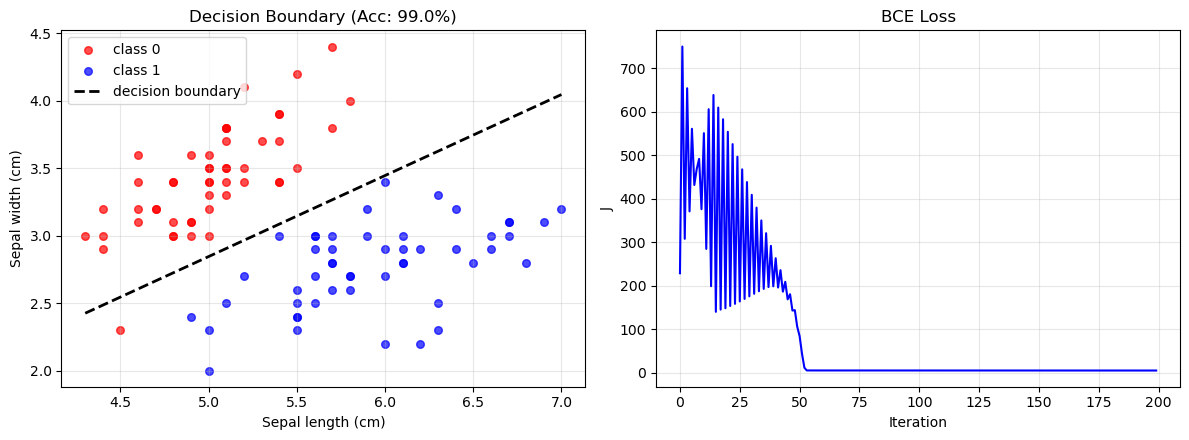

In [6]:
weight_binary = model_binary.linear.weight.detach().numpy().flatten()
bias_binary   = model_binary.linear.bias.item()

print(f'w0 (bias)   = {bias_binary:.4f}')
print(f'w1, w2      = {weight_binary[0]:.4f}, {weight_binary[1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(X_binary_raw[class_0, 0], X_binary_raw[class_0, 1], c='r', s=30, alpha=0.7, label='class 0')
axes[0].scatter(X_binary_raw[class_1, 0], X_binary_raw[class_1, 1], c='b', s=30, alpha=0.7, label='class 1')
x1_line = np.linspace(X_binary_raw[:, 0].min(), X_binary_raw[:, 0].max(), 100)
x2_line = -(bias_binary + weight_binary[0] * x1_line) / weight_binary[1]
axes[0].plot(x1_line, x2_line, 'k--', linewidth=2, label='decision boundary')
axes[0].set_xlabel('Sepal length (cm)')
axes[0].set_ylabel('Sepal width (cm)')
axes[0].set_title(f'Decision Boundary (Acc: {accuracy_binary:.1%})')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(loss_history_binary, 'b-', linewidth=1.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('J')
axes[1].set_title('BCE Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 5. Multi-class — Data

All three species, petal length and width, so the decision regions can be drawn.

`nn.CrossEntropyLoss` expects a **class index** of dtype `int64` and shape $(N,)$ — not one-hot, not float.
The one-hot conversion happens inside the loss.

X_multi: torch.Size([150, 2]), dtype torch.float32
y_multi: torch.Size([150]), dtype torch.int64
classes: [0 1 2] (setosa, versicolor, virginica)


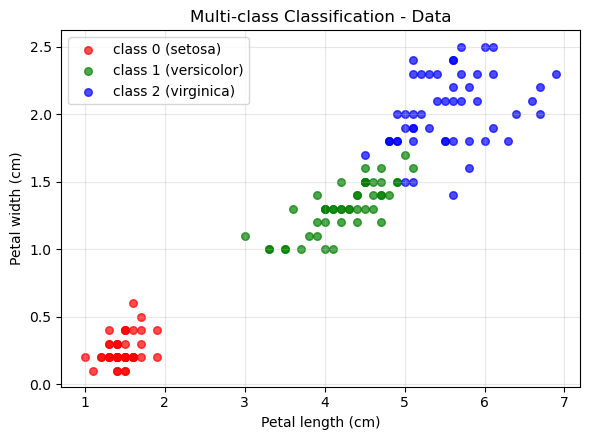

In [7]:
X_multi_raw = iris.data[:, 2:4]     # petal length, petal width
y_multi_raw = iris.target

X_multi = torch.tensor(X_multi_raw, dtype=torch.float32)   # (150, 2)
y_multi = torch.tensor(y_multi_raw, dtype=torch.long)      # (150,) class index

print(f'X_multi: {X_multi.shape}, dtype {X_multi.dtype}')
print(f'y_multi: {y_multi.shape}, dtype {y_multi.dtype}')
print(f'classes: {np.unique(y_multi_raw)} ({", ".join(iris.target_names)})')

plt.figure(figsize=(6, 4.5))
colors = ['r', 'g', 'b']
for k in range(3):
    members = y_multi_raw == k
    plt.scatter(X_multi_raw[members, 0], X_multi_raw[members, 1],
                c=colors[k], s=30, alpha=0.7, label=f'class {k} ({iris.target_names[k]})')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Multi-class Classification - Data')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6. Multi-class Classification — Model and Training

The only change to the model is the number of output units: **one logit per class** instead of one in total.
The `train` function is reused unchanged; only the loss class differs.

In [8]:
class MultiClassifier(torch.nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, num_classes)

    def forward(self, x):
        z = self.linear(x)      # logits, one per class; the softmax is applied inside the loss
        return z


torch.manual_seed(42)
model_multi = MultiClassifier(in_features=2, num_classes=3)
print(model_multi)

MultiClassifier(
  (linear): Linear(in_features=2, out_features=3, bias=True)
)


In [9]:
rho    = 0.005
n_iter = 1000

optimizer = torch.optim.SGD(model_multi.parameters(), lr=rho)
loss_fn   = torch.nn.CrossEntropyLoss(reduction='sum')   # log_softmax + NLL in one

loss_history_multi = train(model_multi, X_multi, y_multi, optimizer, loss_fn, n_iter)

with torch.no_grad():
    logits_multi = model_multi(X_multi)
    y_pred_multi = logits_multi.argmax(dim=1)
    accuracy_multi = (y_pred_multi == y_multi).float().mean().item()

print(f'initial loss : {loss_history_multi[0]:.4f}')
print(f'final loss   : {loss_history_multi[-1]:.4f}')
print(f'accuracy     : {accuracy_multi:.1%}')

initial loss : 359.1762
final loss   : 16.9756
accuracy     : 96.7%


---
## Step 7. Multi-class Classification — Decision Regions

With three classes there are three boundaries, one for each pair.
Rather than plotting the lines, the prediction is evaluated on a grid of points and coloured by the winning
class.
The regions meet along straight lines, which is what makes this a *linear* classifier.

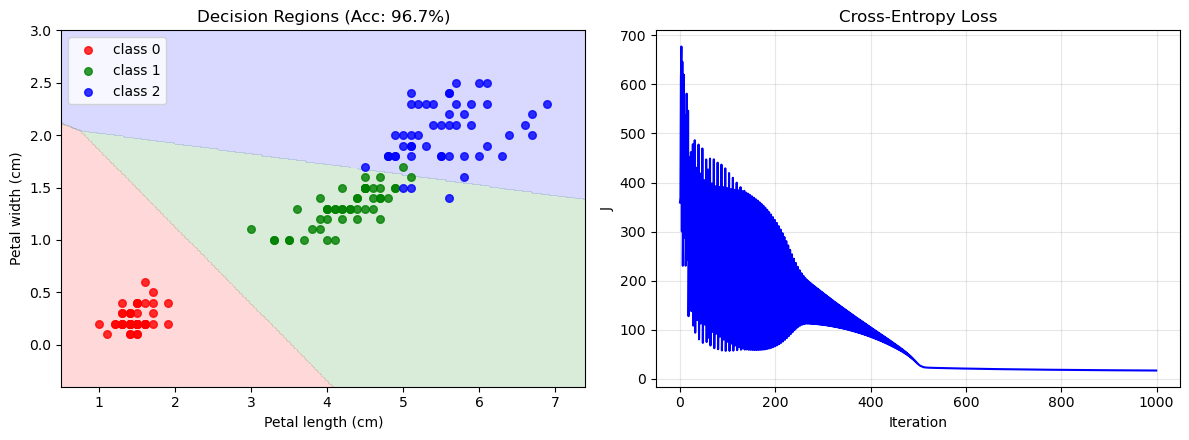

In [10]:
# predict on a grid covering the data range
x1_min, x1_max = X_multi_raw[:, 0].min() - 0.5, X_multi_raw[:, 0].max() + 0.5
x2_min, x2_max = X_multi_raw[:, 1].min() - 0.5, X_multi_raw[:, 1].max() + 0.5
grid_x1, grid_x2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                               np.linspace(x2_min, x2_max, 300))
grid_points = torch.tensor(np.c_[grid_x1.ravel(), grid_x2.ravel()], dtype=torch.float32)

with torch.no_grad():
    grid_class = model_multi(grid_points).argmax(dim=1).numpy().reshape(grid_x1.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].contourf(grid_x1, grid_x2, grid_class, levels=[-0.5, 0.5, 1.5, 2.5], colors=['r', 'g', 'b'], alpha=0.15)
for k in range(3):
    members = y_multi_raw == k
    axes[0].scatter(X_multi_raw[members, 0], X_multi_raw[members, 1],
                    c=colors[k], s=30, alpha=0.8, label=f'class {k}')
axes[0].set_xlabel('Petal length (cm)')
axes[0].set_ylabel('Petal width (cm)')
axes[0].set_title(f'Decision Regions (Acc: {accuracy_multi:.1%})')
axes[0].legend()

axes[1].plot(loss_history_multi, 'b-', linewidth=1.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('J')
axes[1].set_title('Cross-Entropy Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

| | Binary | Multi-class |
|:---|:---|:---|
| Output units | 1 | $C$ |
| Activation | sigmoid | softmax |
| Loss class | `nn.BCEWithLogitsLoss` | `nn.CrossEntropyLoss` |
| Target dtype / shape | `float32`, $(N, 1)$ | `int64`, $(N,)$ |
| Output to label | `sigmoid(z) >= 0.5` | `z.argmax(dim=1)` |
| Boundary in 2D | one line | one per class pair |

- Both models are one `nn.Linear` returning raw logits; only the declaration and loss class differ.
- The call to `train(...)` stays identical, even once hidden layers make it non-linear.